<a href="https://colab.research.google.com/github/samuelrossiello/data-analytics-portfolio/blob/main/bootcamp/week8_sklearn_fundamentals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Exercise 1

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score
%matplotlib inline

# Reload and clean Titanic data
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df = df.drop(columns=["Cabin"])
df["Age"] = df["Age"].fillna(df["Age"].median())
df = df.dropna(subset=["Embarked"])
df["Survived_num"] = df["Survived"].astype(int)
df["Sex_num"] = (df["Sex"] == "female").astype(int)

features = ["Pclass", "Sex_num", "Age", "Fare", "SibSp", "Parch"]
X = df[features]
y = df["Survived_num"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Setup complete!")

Setup complete!


### Exercise 2

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

# For regression we predict Fare instead of Survived
X_reg = df[["Pclass", "Age", "SibSp", "Parch"]]
y_reg = df["Fare"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Train
lr_model = LinearRegression()
lr_model.fit(X_train_reg, y_train_reg)

# Predict
y_pred_reg = lr_model.predict(X_test_reg)

# Evaluate
r2 = r2_score(y_test_reg, y_pred_reg)
rmse = root_mean_squared_error(y_test_reg, y_pred_reg)

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.3207
RMSE: 42.5706


### Exercise 3

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")
print(classification_report(y_test, y_pred_log))

Accuracy: 0.7921
              precision    recall  f1-score   support

           0       0.85      0.81      0.83       109
           1       0.72      0.77      0.74        69

    accuracy                           0.79       178
   macro avg       0.78      0.79      0.78       178
weighted avg       0.80      0.79      0.79       178



### Exercise 4

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7753
              precision    recall  f1-score   support

           0       0.83      0.79      0.81       109
           1       0.69      0.75      0.72        69

    accuracy                           0.78       178
   macro avg       0.76      0.77      0.77       178
weighted avg       0.78      0.78      0.78       178



### Exercise 5

   feature  importance
3     Fare    0.306176
1  Sex_num    0.264975
2      Age    0.250060
0   Pclass    0.084131
4    SibSp    0.053881
5    Parch    0.040777


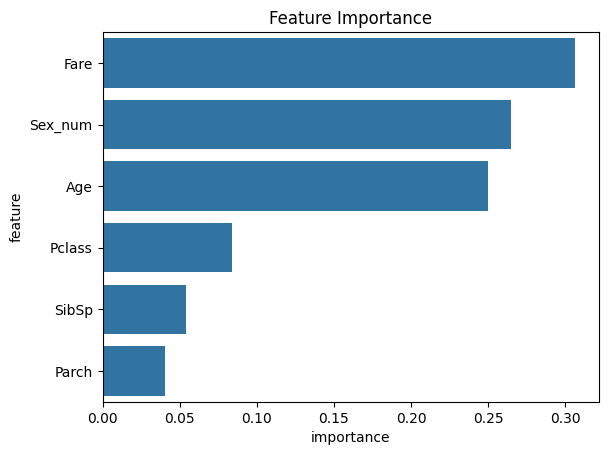

In [ ]:
importance = pd.DataFrame({
    "feature": features,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

print(importance)

sns.barplot(data=importance, x="importance", y="feature")
plt.title("Feature Importance")
plt.show()

### Exercise 6

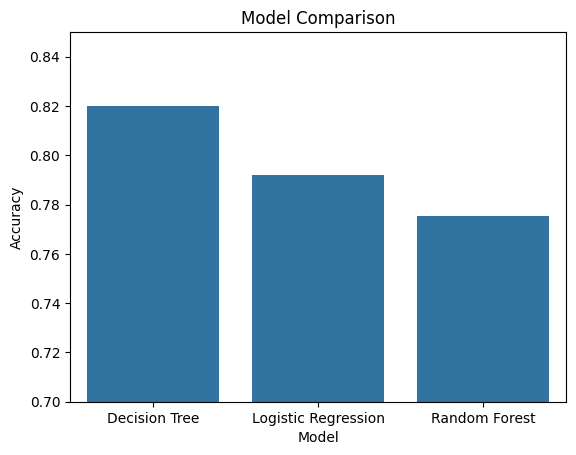

In [ ]:
results = pd.DataFrame({
    "Model": ["Decision Tree", "Logistic Regression", "Random Forest"],
    "Accuracy": [0.8202, 0.7921, 0.7753]
})

sns.barplot(data=results, x="Model", y="Accuracy")
plt.title("Model Comparison")
plt.ylim(0.7, 0.85)
plt.ylabel("Accuracy")
plt.show()

### Exercise 7

   feature  coefficient
1  Sex_num     2.665558
3     Fare     0.002850
2      Age    -0.043845
5    Parch    -0.083896
4    SibSp    -0.400415
0   Pclass    -1.098410


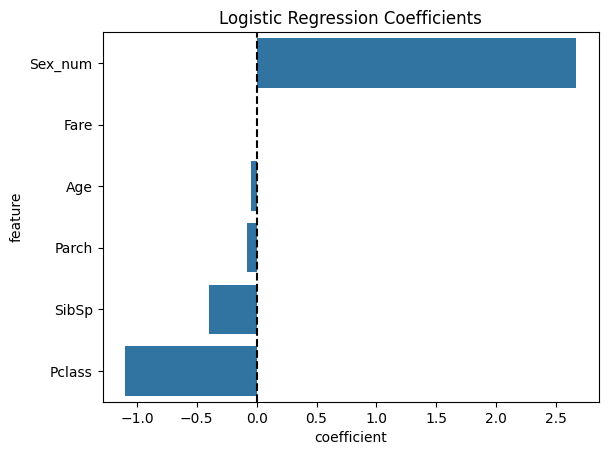

In [ ]:
coef = pd.DataFrame({
    "feature": features,
    "coefficient": log_model.coef_[0]
}).sort_values("coefficient", ascending=False)

print(coef)

sns.barplot(data=coef, x="coefficient", y="feature")
plt.title("Logistic Regression Coefficients")
plt.axvline(x=0, color="black", linestyle="--")
plt.show()

### Practice Project

Define is_alone

In [ ]:
def is_alone(row):
  if (row["SibSp"] == 0) & (row["Parch"] == 0):
    return 1
  else:
    return 0

df["is_alone"] = df.apply(is_alone, axis=1)

print(df[["is_alone","SibSp","Parch"]].head())

   is_alone  SibSp  Parch
0         0      1      0
1         0      1      0
2         1      0      0
3         0      1      0
4         1      0      0


Redefine decision tree

In [ ]:
# Select features and target
features = ["Pclass", "Sex_num", "Age", "Fare", "is_alone"]
X = df[features]
y = df["Survived_num"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create the model
model = DecisionTreeClassifier(random_state=42)

# Train it — this is where the model learns the patterns
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7640


Redefine logistic regression

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")

Accuracy: 0.7865


Redefine random forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")

Accuracy: 0.8202


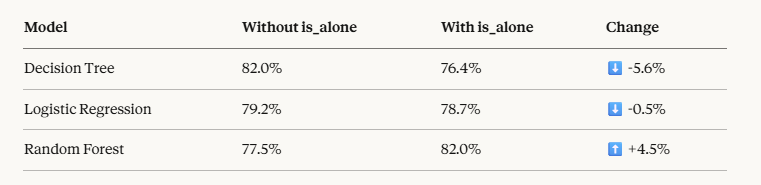

Based on all of the information, I would use the decision tree without is_alone because it is the most accurate and the simplest, without providing redundant or additional features to it

"I would recommend the Decision Tree without the is_alone feature. It achieved the highest accuracy at 82% while remaining the simplest model — making it easy to interpret and explain to non-technical stakeholders. Adding is_alone introduced redundancy without improving performance, and the additional complexity of Random Forest wasn't justified given our dataset size of 889 rows."